# DoublePendulum — Conservative Chaos

## Overview

`DoublePendulum` implements two point masses on rigid, massless rods swinging from a fixed
pivot. The system is Hamiltonian (energy-conserving) with no damping by default, and is
chaotic for most non-trivial initial conditions.

### Equations

$$\frac{d\theta_1}{dt} = \omega_1 \qquad \frac{d\theta_2}{dt} = \omega_2$$

$$\frac{d\omega_1}{dt} = \frac{-g(2m_1+m_2)\sin\theta_1 - m_2 g\sin(\theta_1-2\theta_2)- 2\sin\Delta\,m_2(\omega_2^2 L_2 + \omega_1^2 L_1\cos\Delta)}{L_1[2m_1+m_2-m_2\cos 2\Delta]} - d_1\omega_1$$

$$\frac{d\omega_2}{dt} = \frac{2\sin\Delta(\omega_1^2 L_1(m_1+m_2) + g(m_1+m_2)\cos\theta_1 + \omega_2^2 L_2 m_2\cos\Delta)}{L_2[2m_1+m_2-m_2\cos 2\Delta]} - d_2\omega_2$$

where $\Delta = \theta_1 - \theta_2$.

### Parameters

| Name | Description | Default |
|------|-------------|--------|
| `m1`, `m2` | Bob masses (kg) | 1.0, 1.0 |
| `L1`, `L2` | Rod lengths (m) | 1.0, 1.0 |
| `g` | Gravitational acceleration (m/s²) | 9.81 |
| `d1`, `d2` | Linear damping on each bob (s⁻¹) | 0.0, 0.0 |

State variables: `theta1`, `omega1`, `theta2`, `omega2`. Diagnostics: `energy`, `x1`, `y1`, `x2`, `y2` (Cartesian positions, pivot at origin).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from paleobeasts.signal_models.pendulum import DoublePendulum

## Basic run

Starting from a large-amplitude, asymmetric configuration ($\theta_1 = 120°$, $\theta_2 = -20°$)
the lower bob traces an irregular path — a hallmark of deterministic chaos.

In [2]:
# θ₁=120°, ω₁=0, θ₂=-20°, ω₂=0 — large amplitude, asymmetric
IC = [2 * np.pi / 3, 0.0, -np.pi / 9, 0.0]

dp = DoublePendulum(m1=1.0, m2=1.0, L1=1.0, L2=1.0, g=9.81)
output = dp.integrate(t_span=(0, 30), y0=IC, method='RK45',
                      kwargs={'rtol': 1e-9, 'atol': 1e-11})

t = np.asarray(output.time)
theta1 = np.degrees(output.state_variables['theta1'])
theta2 = np.degrees(output.state_variables['theta2'])
E0 = output.diagnostic_variables['energy'][0]

print(f'Initial energy E₀ = {E0:.4f} J')
print(f'Steps: {len(t)}')

Initial energy E₀ = 0.5916 J
Steps: 3330


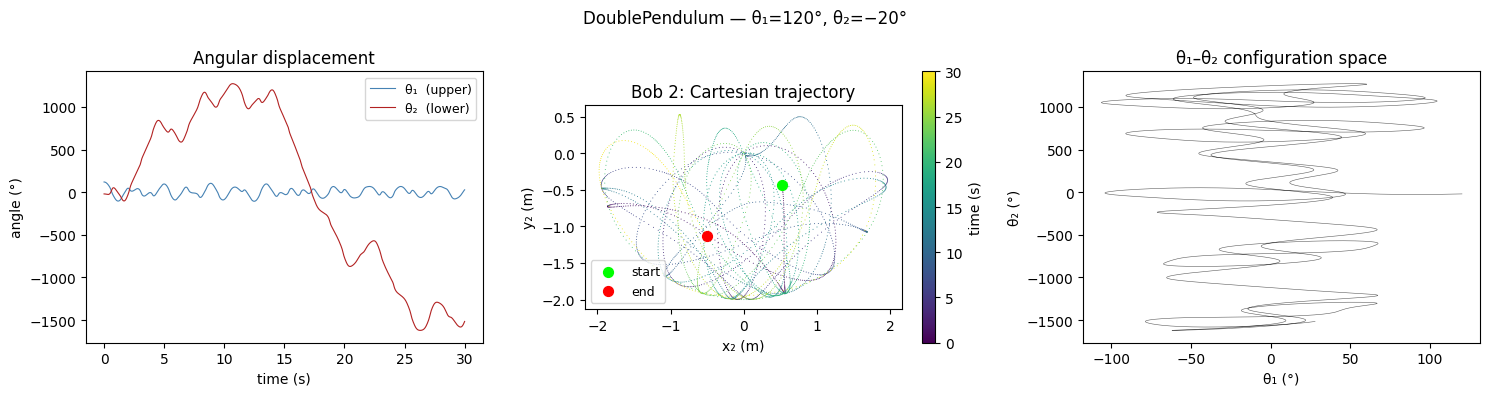

In [3]:
x1 = output.diagnostic_variables['x1']
y1 = output.diagnostic_variables['y1']
x2 = output.diagnostic_variables['x2']
y2 = output.diagnostic_variables['y2']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Angle time series
axes[0].plot(t, theta1, lw=0.8, color='steelblue', label='θ₁  (upper)')
axes[0].plot(t, theta2, lw=0.8, color='firebrick', label='θ₂  (lower)')
axes[0].set_xlabel('time (s)'); axes[0].set_ylabel('angle (°)')
axes[0].set_title('Angular displacement')
axes[0].legend(fontsize=9)

# Bob 2 Cartesian trajectory
sc = axes[1].scatter(x2, y2, c=t, cmap='viridis', s=0.5, lw=0)
axes[1].scatter([x2[0]], [y2[0]], color='lime', s=50, zorder=5, label='start')
axes[1].scatter([x2[-1]], [y2[-1]], color='red',  s=50, zorder=5, label='end')
fig.colorbar(sc, ax=axes[1], label='time (s)')
axes[1].set_xlabel('x₂ (m)'); axes[1].set_ylabel('y₂ (m)')
axes[1].set_title('Bob 2: Cartesian trajectory')
axes[1].set_aspect('equal')
axes[1].legend(fontsize=9)

# θ₁–θ₂ phase portrait
axes[2].plot(theta1, theta2, lw=0.4, color='#333333', alpha=0.8)
axes[2].set_xlabel('θ₁ (°)'); axes[2].set_ylabel('θ₂ (°)')
axes[2].set_title('θ₁–θ₂ configuration space')

fig.suptitle('DoublePendulum — θ₁=120°, θ₂=−20°')
plt.tight_layout(); plt.show()

## Sensitive dependence on initial conditions

Two trajectories starting $\varepsilon = 10^{-6}$ rad apart in $\theta_1$ diverge
exponentially and become fully uncorrelated within a few seconds.

In [4]:
eps = 1e-6
kw_tight = {'rtol': 1e-10, 'atol': 1e-12}

dp_a = DoublePendulum()
out_a = dp_a.integrate(t_span=(0, 20), y0=IC, method='RK45', kwargs=kw_tight)

IC_perturbed = [IC[0] + eps, IC[1], IC[2], IC[3]]
dp_b = DoublePendulum()
out_b = dp_b.integrate(t_span=(0, 20), y0=IC_perturbed, method='RK45', kwargs=kw_tight)

t_a = np.asarray(out_a.time)
t_b = np.asarray(out_b.time)

# Interpolate b onto a's time grid for pointwise comparison
th1_b_interp = np.interp(t_a, t_b, out_b.state_variables['theta1'])
th2_b_interp = np.interp(t_a, t_b, out_b.state_variables['theta2'])
om1_b_interp = np.interp(t_a, t_b, out_b.state_variables['omega1'])
om2_b_interp = np.interp(t_a, t_b, out_b.state_variables['omega2'])

sep = np.sqrt(
    (out_a.state_variables['theta1'] - th1_b_interp)**2 +
    (out_a.state_variables['theta2'] - th2_b_interp)**2 +
    (out_a.state_variables['omega1'] - om1_b_interp)**2 +
    (out_a.state_variables['omega2'] - om2_b_interp)**2
)

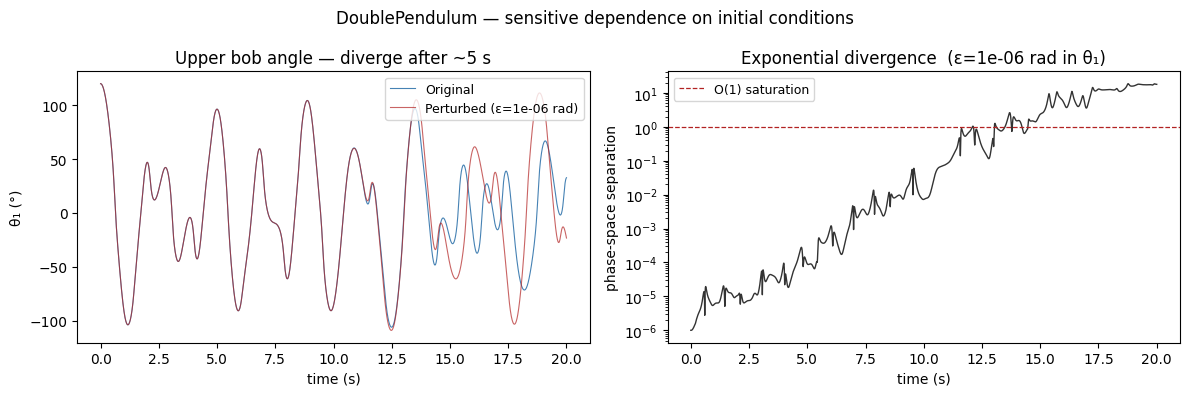

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_a, np.degrees(out_a.state_variables['theta1']),
             lw=0.8, color='steelblue', label='Original')
axes[0].plot(t_b, np.degrees(out_b.state_variables['theta1']),
             lw=0.8, color='firebrick', alpha=0.7, label=f'Perturbed (ε={eps:.0e} rad)')
axes[0].set_xlabel('time (s)'); axes[0].set_ylabel('θ₁ (°)')
axes[0].set_title('Upper bob angle — diverge after ~5 s')
axes[0].legend(fontsize=9)

axes[1].semilogy(t_a, sep + 1e-18, lw=1.0, color='#333333')
axes[1].axhline(1.0, color='firebrick', ls='--', lw=0.9, label='O(1) saturation')
axes[1].set_xlabel('time (s)'); axes[1].set_ylabel('phase-space separation')
axes[1].set_title(f'Exponential divergence  (ε={eps:.0e} rad in θ₁)')
axes[1].legend(fontsize=9)

fig.suptitle('DoublePendulum — sensitive dependence on initial conditions')
plt.tight_layout(); plt.show()

## Energy conservation vs solver tolerance

The undamped double pendulum is Hamiltonian — total energy is an exact constant.
Relative energy error $|E(t)-E_0|/|E_0|$ measures integration quality.

In [6]:
tol_cases = [
    ('Default  (rtol=1e-3)', {},                              'firebrick'),
    ('Moderate (rtol=1e-6)', {'rtol': 1e-6, 'atol': 1e-8},   'goldenrod'),
    ('Tight    (rtol=1e-10)',{'rtol': 1e-10,'atol': 1e-12},   'steelblue'),
]

for label, kw, _ in tol_cases:
    m = DoublePendulum()
    out = m.integrate(t_span=(0, 40), y0=IC, method='RK45', kwargs=kw)
    E = out.diagnostic_variables['energy']
    max_err = np.max(np.abs(E - E[0])) / np.abs(E[0])
    print(f'{label:35s}  steps={len(out.time):5d}  max|ΔE/E₀|={max_err:.2e}')

Default  (rtol=1e-3)                 steps=  337  max|ΔE/E₀|=1.58e+01
Moderate (rtol=1e-6)                 steps= 1092  max|ΔE/E₀|=2.26e-03
Tight    (rtol=1e-10)                steps= 7191  max|ΔE/E₀|=1.45e-08


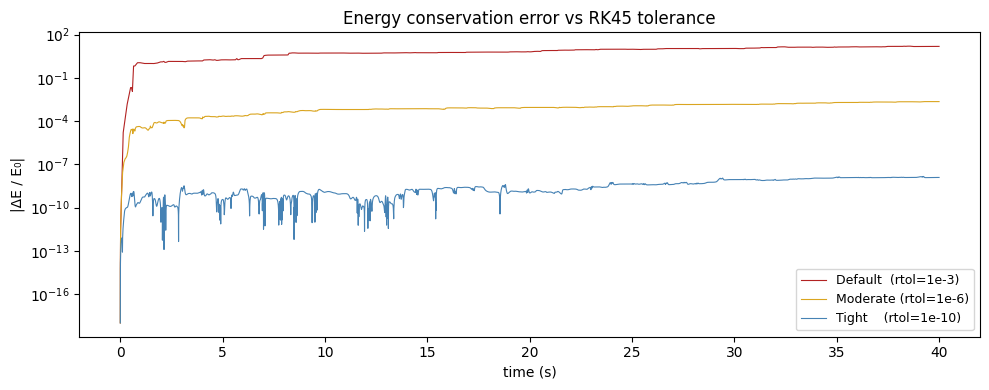

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))

for label, kw, color in tol_cases:
    m = DoublePendulum()
    out = m.integrate(t_span=(0, 40), y0=IC, method='RK45', kwargs=kw)
    E = out.diagnostic_variables['energy']
    ax.semilogy(np.asarray(out.time), np.abs(E - E[0]) / np.abs(E[0]) + 1e-18,
                lw=0.8, color=color, label=label)

ax.set_xlabel('time (s)'); ax.set_ylabel('|ΔE / E₀|')
ax.set_title('Energy conservation error vs RK45 tolerance')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## Solver notes

`RK45` (adaptive) is the recommended solver. Default tolerances are adequate for short
qualitative runs; for energy-sensitive diagnostics use tight tolerances:

```python
output = model.integrate(..., kwargs={'rtol': 1e-9, 'atol': 1e-11})
```

**Optional damping:** set `d1` and/or `d2` to positive values to add linear damping on
each bob. With damping the system is no longer Hamiltonian and energy decays monotonically.

**Cartesian positions** (`x1`, `y1`, `x2`, `y2`) are computed from angles after integration
and accessible via `output.diagnostic_variables` or `model.cartesian_positions()`.

**Note:** A `MultiPendulum` class supporting N-rod chains is not yet in the public codebase.
For $N>2$ rods the recommended approach is to subclass `DoublePendulum` and override `dydt`
using the Lagrangian mass-matrix formulation, solving $M(\theta)\,\ddot{\theta} = \tau(\theta,\dot{\theta})$
with `numpy.linalg.solve` at each step.